# 01 Data Audit

IMPORTS

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [33]:
DATA_PATH = "../data/raw/data.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(1737585, 14)


,TimeStamp,02FI_1000.PV,03FIC_1085.PV,03FI_3418.PV,03LIC_1094.PV,03PIC_1104.PV,03TIC_1009.PV,03TIC_1092.PV,03TI_1002.PV,03TI_1005.PV,03TI_1081.PV,03TI_1102.PV,03TI_1108.PV,03TI_1404.PV
0,2022-01-03 22:45:00,6.645525,216.82233,30.962135,52.072630,25.146055,35.456966,4.624359,45.199110,42.732693,-36.141970,NaN,31.587097,36.090870
1,2022-01-03 22:46:00,6.682778,210.55800,32.483753,54.947033,25.226107,35.332653,4.643196,45.199110,42.401283,-36.198616,10.000004,31.564457,36.251778
2,2022-01-03 22:47:00,6.713386,212.94440,31.975134,55.953170,25.315577,35.016205,4.605526,45.199110,42.600132,-36.283580,9.962143,31.587097,36.280174
3,2022-01-03 22:48:00,6.706837,213.07224,32.305733,55.358322,25.400337,35.389156,4.793884,45.199110,42.495970,-36.297745,9.858025,31.598423,36.176056
4,2022-01-03 22:49:00,6.670256,214.64897,31.852217,56.762740,25.452137,35.287450,4.793884,45.227604,42.401283,-36.241100,9.734978,31.598423,36.251778


In [34]:
df.info()
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

<class 'pandas.DataFrame'>
RangeIndex: 1737585 entries, 0 to 1737584
Data columns (total 14 columns):
 #   Column         Dtype  
---  ------         -----  
 0   TimeStamp      str    
 1   02FI_1000.PV   float64
 2   03FIC_1085.PV  float64
 3   03FI_3418.PV   float64
 4   03LIC_1094.PV  float64
 5   03PIC_1104.PV  float64
 6   03TIC_1009.PV  float64
 7   03TIC_1092.PV  float64
 8   03TI_1002.PV   float64
 9   03TI_1005.PV   float64
 10  03TI_1081.PV   float64
 11  03TI_1102.PV   float64
 12  03TI_1108.PV   float64
 13  03TI_1404.PV   float64
dtypes: float64(13), str(1)
memory usage: 217.1 MB
Rows: 1,737,585
Columns: 14


In [35]:
TARGET = "03TIC_1009.PV"

In [36]:
df["TimeStamp"]=pd.to_datetime(df["TimeStamp"])

df=df.sort_values("TimeStamp").reset_index(drop=True)
print(df["TimeStamp"].min())
print(df["TimeStamp"].max())
duration = (
    df["TimeStamp"].max()
    - df["TimeStamp"].min()
)

print(duration)

2022-01-03 22:45:00
2025-06-23 20:44:00
1266 days 21:59:00


In [37]:
# duplicate timestamps

duplicates = df["TimeStamp"].duplicated().sum()

print(duplicates)

0


In [38]:
# sampling frequency

time_diff = (
    df["TimeStamp"]
    .diff()
    .dropna()
)

time_diff.value_counts().head(10)

TimeStamp
0 days 00:01:00    1737490
0 days 00:02:00         44
0 days 00:03:00          8
0 days 08:02:00          1
0 days 03:18:00          1
0 days 09:01:00          1
1 days 22:02:00          1
1 days 07:42:00          1
0 days 05:37:00          1
0 days 13:31:00          1
Name: count, dtype: int64

In [39]:
#missing values
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing
missing_percent = (
    df.isnull().mean()*100
)

missing_percent.sort_values(
    ascending=False
)

03TI_1002.PV     0.174955
02FI_1000.PV     0.038387
03FIC_1085.PV    0.015078
03FI_3418.PV     0.000460
03TI_1404.PV     0.000460
03PIC_1104.PV    0.000403
03TI_1108.PV     0.000403
03TI_1005.PV     0.000230
03TI_1081.PV     0.000230
03TI_1102.PV     0.000230
03LIC_1094.PV    0.000173
03TIC_1009.PV    0.000173
03TIC_1092.PV    0.000173
TimeStamp        0.000000
dtype: float64

In [40]:
df.describe().T
df[TARGET].describe()

count    1.737582e+06
mean     4.238631e+01
std      4.428034e+00
min     -1.989793e+01
25%      3.971765e+01
50%      4.181973e+01
75%      4.432867e+01
max      7.001706e+01
Name: 03TIC_1009.PV, dtype: float64

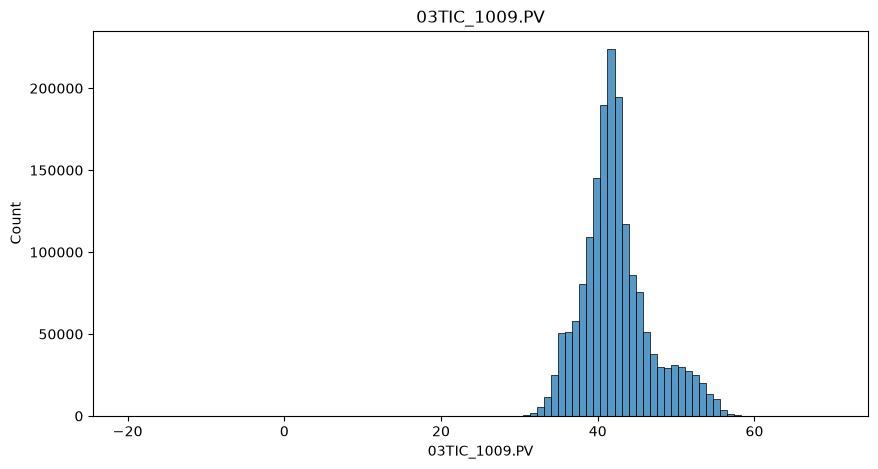

In [41]:
from pandas import plotting
plt.figure(figsize=(10,5))

sns.histplot(
    df[TARGET],
    bins=100
)

plt.title(TARGET)
plt.show()

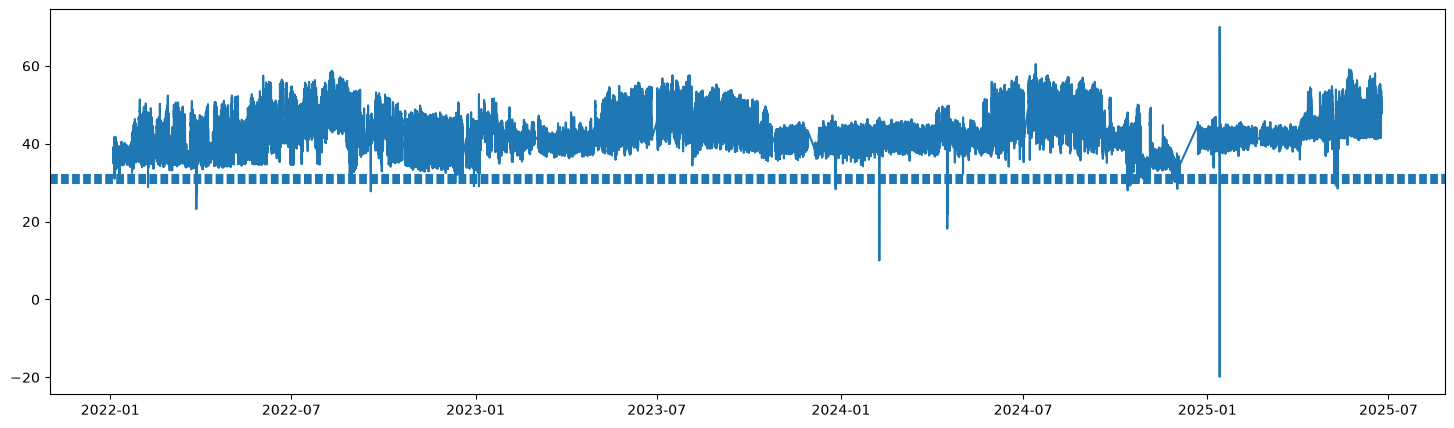

In [42]:
# threshold exploration
thresholds = [30,30.5,31,31.5,32]

plt.figure(figsize=(18,5))

plt.plot(
    df["TimeStamp"],
    df[TARGET]
)

for t in thresholds:
    plt.axhline(
        t,
        linestyle="--"
    )

plt.show()

In [43]:
df.to_parquet(
    "../data/interim/data_sorted.parquet",
    index=False
)